# PyPSA Energy System Optimization - Exploratory Analysis
 
This notebook provides an interactive environment for exploring the PyPSA energy system model.
 
**Contents:**
1. Setup and Data Loading
2. Network Topology Visualization
3. Time Series Data Exploration
4. Single Scenario Analysis
5. Multi-Scenario Comparison
6. Interactive Parameter Exploration

In [1]:
# Standard imports
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Add src to path - handle both running from notebook dir and project root
notebook_path = Path(__file__).parent if '__file__' in dir() else Path.cwd()
project_root = notebook_path.parent if notebook_path.name == 'notebooks' else notebook_path
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Alternative: add project root for absolute imports
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# PyPSA imports
import pypsa

# Project modules - use absolute imports
from config_loader import load_scenario_config, get_scenario_names
from load_data import get_data_for_scenario, create_synthetic_profiles
from build_network import build_network
from run_optimization import run_optimization, analyze_results, compare_scenarios
from plotting import (
    plot_generation_mix,
    plot_storage_operation,
    plot_network_diagram,
    plot_daily_profile,
    plot_scenario_comparison
)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("✓ Setup complete")
print(f"  Project root: {project_root}")
print(f"  Src path: {src_path}")

✓ Setup complete
  Project root: c:\Users\qsamudio\OneDrive - Université Paris Sciences et Lettres\Documents\PythonScripts\PypsaExplore
  Src path: c:\Users\qsamudio\OneDrive - Université Paris Sciences et Lettres\Documents\PythonScripts\PypsaExplore\src


## 1. Available Scenarios

Let's first check which scenarios are defined in the configuration.

In [2]:
scenarios = get_scenario_names()
print("Available scenarios:")
for s in scenarios:
    config = load_scenario_config(s)
    print(f"  • {s}: {config.get('description', 'No description')}")

Available scenarios:
  • baseline: Classical generation mix with high fossil fuel dependence
  • high_renewable: High penetration of renewables with extended storage capacity
  • net_zero: Net-zero emissions scenario with 100% renewable target and extended storage


## 2. Load and Explore Time Series Data

Examine the demand profiles and renewable capacity factors.

In [3]:
# Load baseline config to get data paths
config = load_scenario_config('baseline')

# Load data
data = get_data_for_scenario(config, data_dir='../data')

print(f"Data shape: {data.shape}")
print(f"\nColumns:")
print(data.columns.tolist())
print(f"\nDate range: {data.index[0]} to {data.index[-1]}")

# Display summary statistics
data.describe()

Data shape: (8760, 6)

Columns:
['demand_north', 'demand_south', 'wind_north', 'wind_south', 'solar_north', 'solar_south']

Date range: 2024-01-01 00:00:00 to 2024-12-30 23:00:00


,demand_north,demand_south,wind_north,wind_south,solar_north,solar_south
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,968.849434,1190.294488,0.351083,0.251284,0.297567,0.369705
std,236.339747,468.361782,0.166574,0.103963,0.315790,0.390805
min,561.366210,600.000000,0.000000,0.000000,0.000000,0.000000
25%,671.828122,624.393812,0.235043,0.179571,0.000000,0.000000
50%,946.593095,1201.058074,0.350492,0.251695,0.178564,0.223086
75%,1197.003351,1697.127331,0.465473,0.321636,0.624402,0.781804
max,1288.598988,1911.715246,1.000000,0.651531,0.937140,1.000000


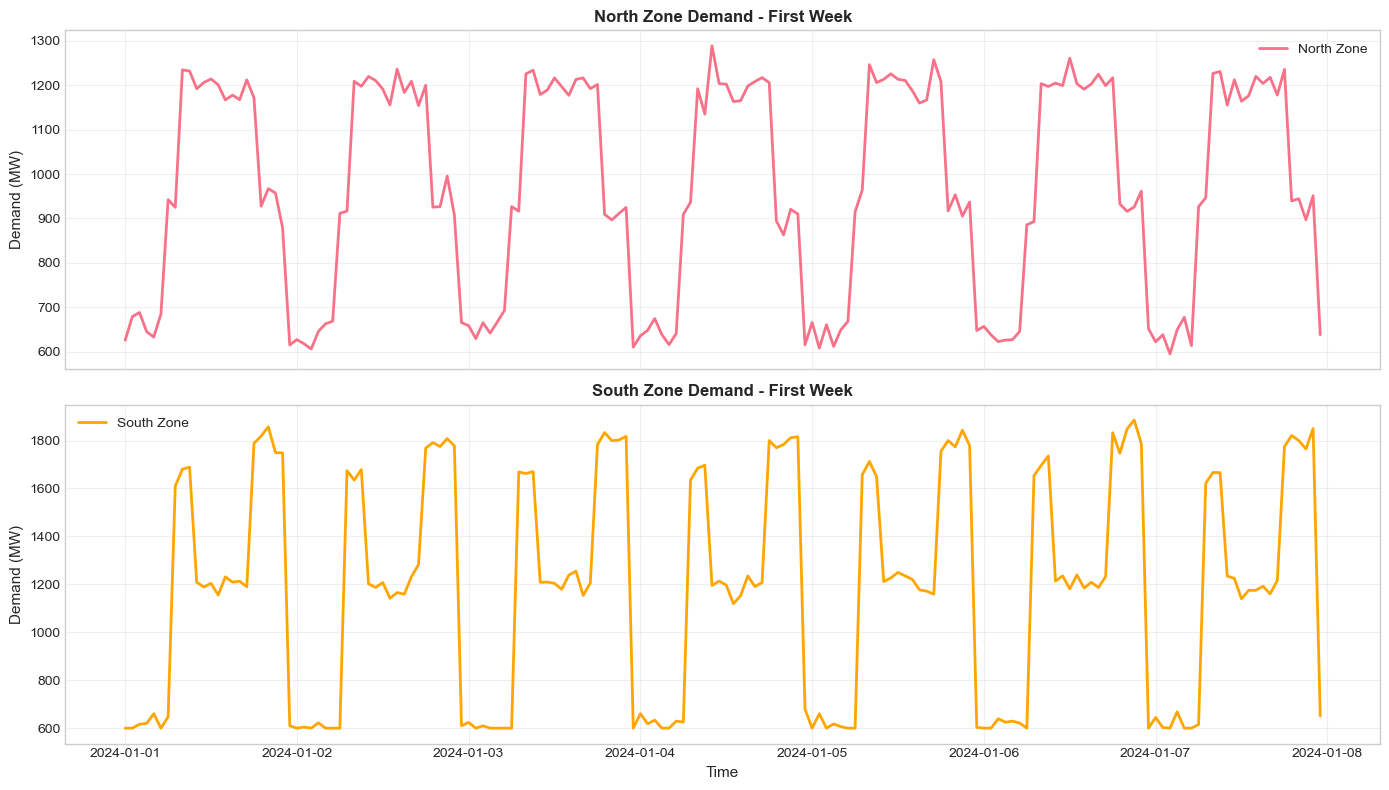

In [4]:
# Plot demand profiles (first week)
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

week_data = data.iloc[:168]  # First week

# North demand
axes[0].plot(week_data.index, week_data['demand_north'], linewidth=2, label='North Zone')
axes[0].set_ylabel('Demand (MW)', fontsize=11)
axes[0].set_title('North Zone Demand - First Week', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# South demand
axes[1].plot(week_data.index, week_data['demand_south'], linewidth=2, color='orange', label='South Zone')
axes[1].set_ylabel('Demand (MW)', fontsize=11)
axes[1].set_title('South Zone Demand - First Week', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.xlabel('Time', fontsize=11)
plt.tight_layout()
plt.show()

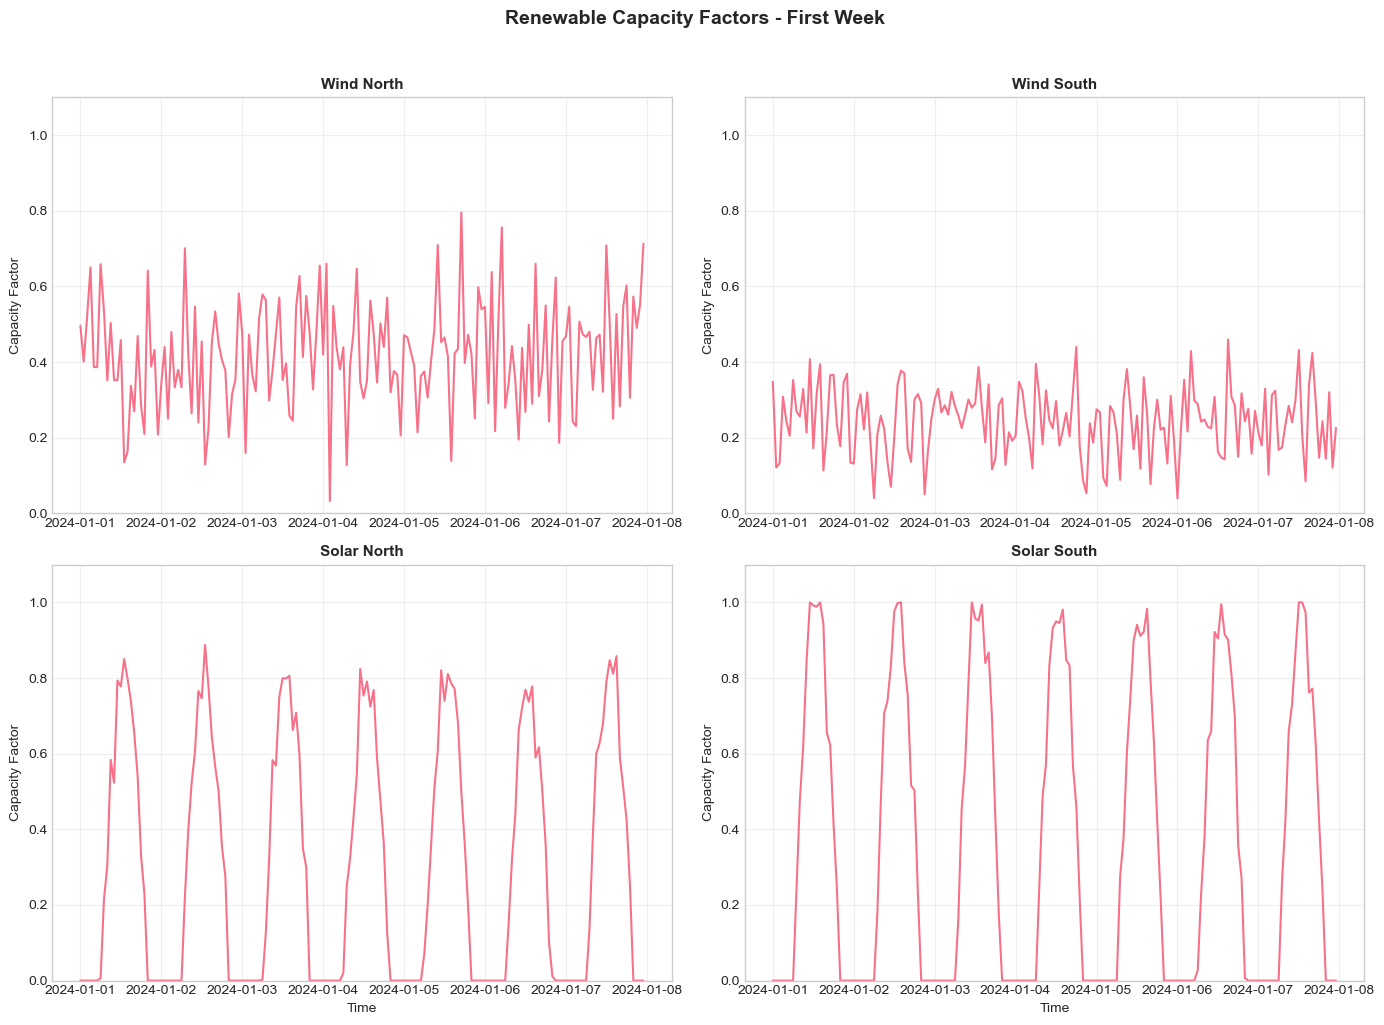

In [5]:
# Plot renewable profiles
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

renewables = ['wind_north', 'wind_south', 'solar_north', 'solar_south']
titles = ['Wind North', 'Wind South', 'Solar North', 'Solar South']

for idx, (ax, col, title) in enumerate(zip(axes.flatten(), renewables, titles)):
    ax.plot(week_data.index, week_data[col], linewidth=1.5)
    ax.set_ylabel('Capacity Factor', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.grid(True, alpha=0.3)

axes[1, 0].set_xlabel('Time', fontsize=10)
axes[1, 1].set_xlabel('Time', fontsize=10)

plt.suptitle('Renewable Capacity Factors - First Week', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Build and Visualize Network

Create a PyPSA network and visualize its topology.

In [6]:
# Use first 168 hours (1 week) for quick testing
test_data = data.iloc[:168]

# Build network
network = build_network(config, test_data, scenario_name='baseline')

print("\nNetwork Summary:")
print(f"  Buses: {len(network.buses)}")
print(f"  Lines: {len(network.lines)}")
print(f"  Generators: {len(network.generators)}")
print(f"  Storage Units: {len(network.storage_units)}")
print(f"  Loads: {len(network.loads)}")

Building network for scenario: baseline
  Added bus: North
  Added bus: South
  Added line: North_South (North <-> South)
  Added load: North_Load (avg: 969.7 MW)
  Added load: South_Load (avg: 1188.4 MW)
  Added generator: North_Wind (wind, 400 MW)
  Added generator: North_Solar (solar, 200 MW)
  Added generator: North_Gas (gas, 300 MW) (extendable)
  Added generator: South_Wind (wind, 150 MW)
  Added generator: South_Solar (solar, 600 MW)
  Added generator: South_Gas (gas, 500 MW) (extendable)
  Added storage: North_Battery (200 MW, 800 MWh)
  Added storage: South_Battery (400 MW, 1600 MWh)

Network summary:
  Buses: 2
  Lines: 1
  Generators: 6
  Storage Units: 2
  Time steps: 168

Network Summary:
  Buses: 2
  Lines: 1
  Generators: 6
  Storage Units: 2
  Loads: 2


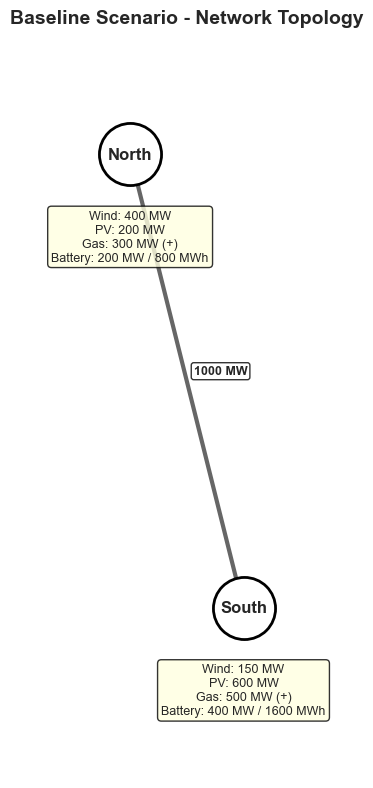

In [7]:
# Visualize network topology
fig = plot_network_diagram(network, figsize=(12, 8),
                          title='Baseline Scenario - Network Topology')
plt.show()

In [8]:
# Display generator information
print("Generators:")
network.generators[['bus', 'carrier', 'p_nom', 'p_nom_extendable', 'marginal_cost']]

Generators:


,bus,carrier,p_nom,p_nom_extendable,marginal_cost
name,,,,,
North_Wind,North,wind,400.0,False,0.0
North_Solar,North,solar,200.0,False,0.0
North_Gas,North,gas,300.0,True,50.0
South_Wind,South,wind,150.0,False,0.0
South_Solar,South,solar,600.0,False,0.0
South_Gas,South,gas,500.0,True,50.0


## 4. Run Optimization

Solve the optimal power flow problem.

In [9]:
# Run optimization
success = run_optimization(network, solver_name='cbc', verbose=True)

if success:
    print("\n✓ Optimization successful!")
else:
    print("\n✗ Optimization failed")


Starting Optimization
Solver: cbc
Time steps: 168
Variables: ~1344


INFO:linopy.model: Solve problem using Cbc solver
INFO:linopy.model:Solver options:
 - threads: 4
 - time_limit: 3600
 - log_file: results/solver.log
INFO:linopy.io: Writing time: 0.09s
INFO:linopy.solvers:No match for threads - ? for list of commands
No match for 4 - ? for list of commands
No match for time_limit - ? for list of commands
No match for 3600 - ? for list of commands
No match for log_file - ? for list of commands
No match for results/solver.log - ? for list of commands
Total time (CPU seconds):       0.04   (Wallclock seconds):       0.04


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2186 primals, 5044 duals
Objective: 1.67e+09
Solver model: available
Solver message: Optimal - objective value 1669989838.54851818


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Storage


Optimization Complete - SUCCESS
Objective value: 1669.99 M€
Termination condition: OK

✓ Optimization successful!


In [10]:
# Analyze results
results = analyze_results(network)

print("\nKey Performance Indicators:")
print(f"  Total System Cost: {results['objective_value_eur']/1e6:.2f} M€")
print(f"  Total Demand: {results['total_demand_mwh']/1000:.1f} GWh")
print(f"  Renewable Share: {results['renewable_share']*100:.1f}%")
print(f"  CO2 Emissions: {results['co2_emissions_ton']/1000:.1f} kt")
print(f"  Curtailment: {results['curtailment_mwh']/1000:.1f} GWh")

print("\nGeneration by Carrier:")
for carrier, gen in results['total_generation_mwh'].items():
    print(f"  {carrier}: {gen/1000:.1f} GWh")


Key Performance Indicators:
  Total System Cost: 1669.99 M€
  Total Demand: 362.6 GWh
  Renewable Share: 22.4%
  CO2 Emissions: 99.1 kt
  Curtailment: 0.0 GWh

Generation by Carrier:
  wind: 34.3 GWh
  solar: 47.1 GWh
  gas: 283.0 GWh


## 5. Visualize Results

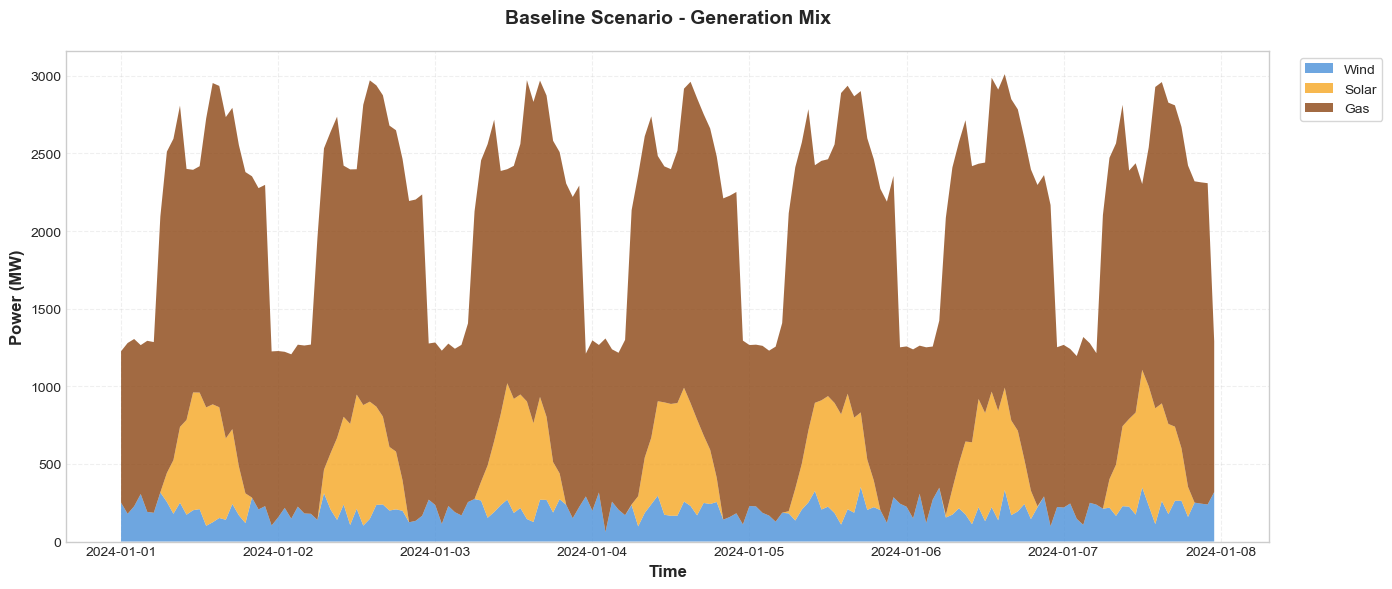

In [11]:
# Generation mix over time
fig = plot_generation_mix(network, figsize=(14, 6),
                         title='Baseline Scenario - Generation Mix')
plt.show()

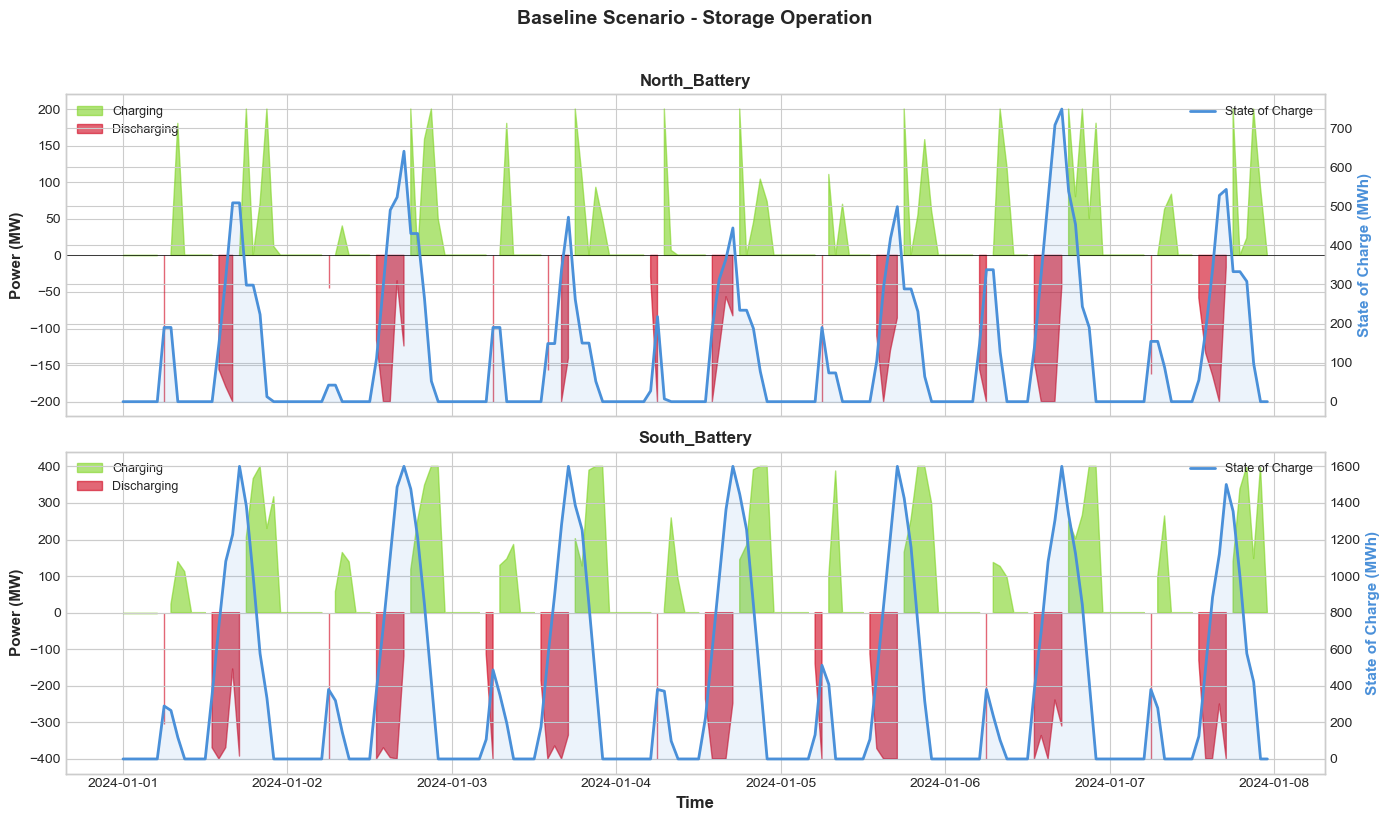

In [12]:
# Storage operation
if len(network.storage_units) > 0:
    fig = plot_storage_operation(network, figsize=(14, 8),
                              title='Baseline Scenario - Storage Operation')
    plt.show()

c:\Users\qsamudio\OneDrive - Université Paris Sciences et Lettres\Documents\PythonScripts\PypsaExplore\src\plotting.py:383: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot(range(24), total_demand, 'k-', linewidth=2, label='Demand', linestyle='--')


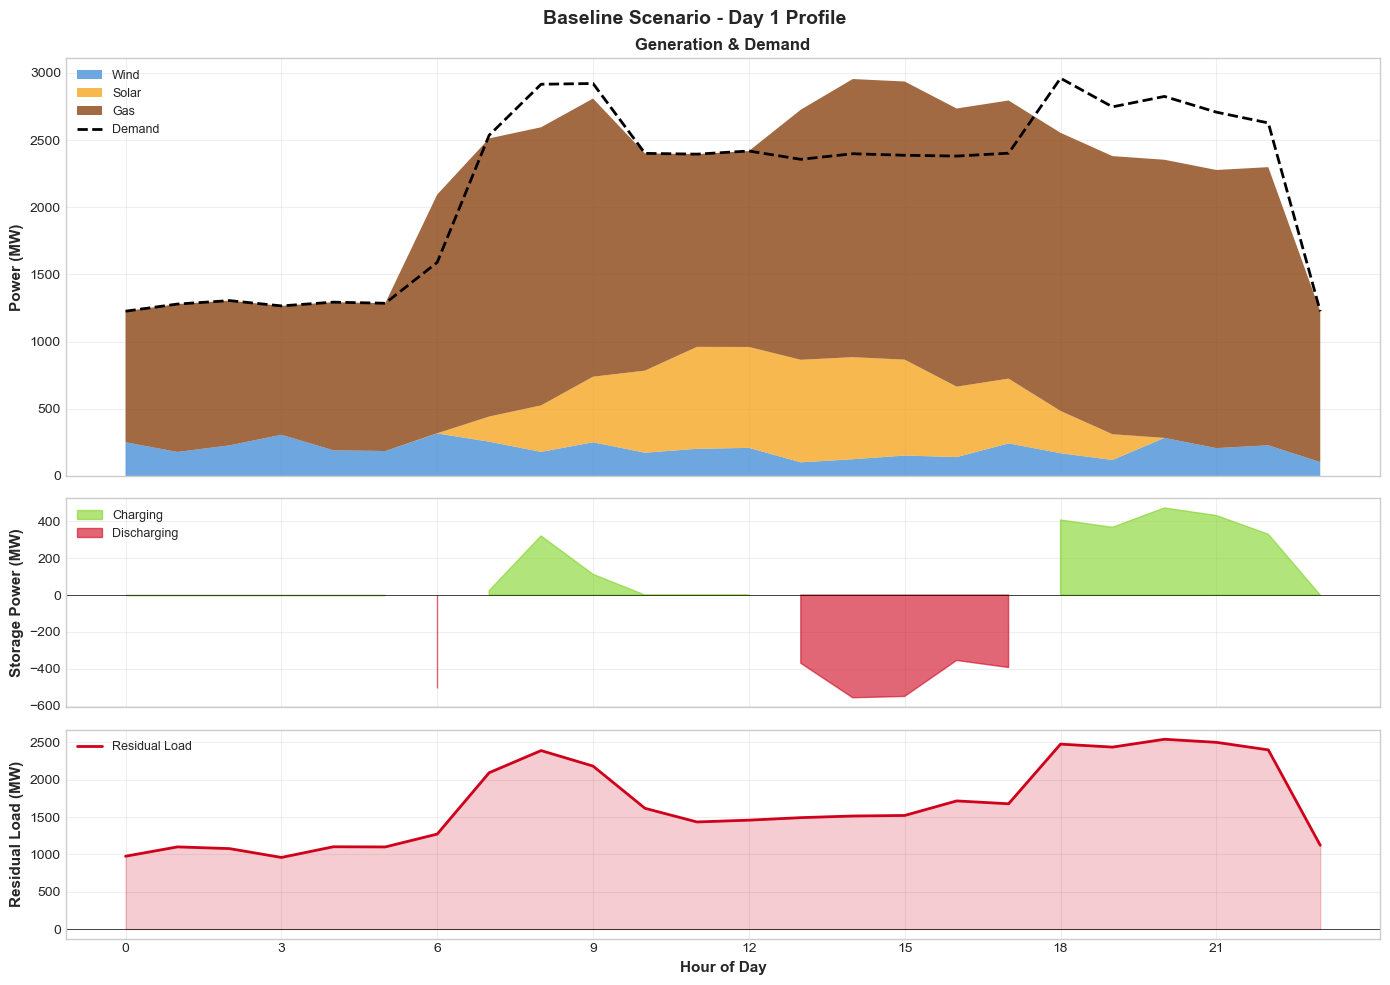

In [13]:
# Daily profile
fig = plot_daily_profile(network, day=1, figsize=(14, 10),
                        title='Baseline Scenario - Day 1 Profile')
plt.show()

## 6. Compare Scenarios

Run and compare multiple scenarios.

In [14]:
# Run multiple scenarios
scenarios_to_run = ['baseline', 'high_renewable']
all_results = {}

for scenario_name in scenarios_to_run:
    print(f"\n{'='*60}")
    print(f"Running {scenario_name}...")
    
    # Load config and build network
    config = load_scenario_config(scenario_name)
    data = get_data_for_scenario(config, data_dir='../data')
    data = data.iloc[:168]  # Use 1 week for quick comparison
    
    network = build_network(config, data, scenario_name)
    
    # Run optimization
    success = run_optimization(network, solver_name='cbc', verbose=False)
    
    if success:
        results = analyze_results(network)
        all_results[scenario_name] = results
        print(f"  ✓ Completed - Cost: {results['objective_value_eur']/1e6:.2f} M€")
    else:
        print(f"  ✗ Failed")


Running baseline...
Building network for scenario: baseline
  Added bus: North
  Added bus: South
  Added line: North_South (North <-> South)


  Added load: North_Load (avg: 969.7 MW)
  Added load: South_Load (avg: 1188.4 MW)
  Added generator: North_Wind (wind, 400 MW)
  Added generator: North_Solar (solar, 200 MW)
  Added generator: North_Gas (gas, 300 MW) (extendable)
  Added generator: South_Wind (wind, 150 MW)
  Added generator: South_Solar (solar, 600 MW)
  Added generator: South_Gas (gas, 500 MW) (extendable)
  Added storage: North_Battery (200 MW, 800 MWh)
  Added storage: South_Battery (400 MW, 1600 MWh)

Network summary:
  Buses: 2
  Lines: 1
  Generators: 6
  Storage Units: 2
  Time steps: 168


INFO:linopy.model: Solve problem using Cbc solver
INFO:linopy.model:Solver options:
 - threads: 4
 - time_limit: 3600
 - log_file: results/solver.log
INFO:linopy.io: Writing time: 0.08s
INFO:linopy.solvers:No match for threads - ? for list of commands
No match for 4 - ? for list of commands
No match for time_limit - ? for list of commands
No match for 3600 - ? for list of commands
No match for log_file - ? for list of commands
No match for results/solver.log - ? for list of commands
Total time (CPU seconds):       0.04   (Wallclock seconds):       0.04


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2186 primals, 5044 duals
Objective: 1.67e+09
Solver model: available
Solver message: Optimal - objective value 1669989838.54851818


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, Storage

  ✓ Completed - Cost: 1669.99 M€

Running high_renewable...
Building network for scenario: high_renewable
  Added bus: North
  Added bus: South
  Added line: North_South (North <-> South)
  Added load: North_Load (avg: 969.7 MW)
  Added load: South_Load (avg: 1188.4 MW)
  Added generator: North_Wind (wind, 1500 MW) (extendable)
  Added generator: North_Solar (solar, 400 MW) (extendable)
  Added generator: North_Gas (gas, 100 MW) (extendable)
  Added generator: South_Wind (wind, 600 MW) (extendable)


  Added generator: South_Solar (solar, 2000 MW) (extendable)
  Added generator: South_Gas (gas, 200 MW) (extendable)
  Added storage: North_Battery (800 MW, 4800 MWh (extendable))
  Added storage: South_Battery (1200 MW, 7200 MWh (extendable))

Network summary:
  Buses: 2
  Lines: 1
  Generators: 6
  Storage Units: 2
  Time steps: 168


INFO:linopy.model: Solve problem using Cbc solver
INFO:linopy.model:Solver options:
 - threads: 4
 - time_limit: 3600
 - log_file: results/solver.log
INFO:linopy.io: Writing time: 0.09s
INFO:linopy.solvers:No match for threads - ? for list of commands
No match for 4 - ? for list of commands
No match for time_limit - ? for list of commands
No match for 3600 - ? for list of commands
No match for log_file - ? for list of commands
No match for results/solver.log - ? for list of commands
Total time (CPU seconds):       0.11   (Wallclock seconds):       0.11


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2192 primals, 5056 duals
Objective: 2.74e+09
Solver model: available
Solver message: Optimal - objective value 2740775930.83691216


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_d

  ✓ Completed - Cost: 2740.78 M€


,Total Cost (M€),Total Demand (TWh),Renewable Share (%),CO2 Emissions (kt),Curtailment (GWh),Wind (GWh),Solar (GWh),Gas (GWh),Storage Utilization (%)
Scenario,,,,,,,,,
baseline,1669.989839,0.362562,22.353699,99.065261,4.389951e-08,34.344395,47.141411,283.043602,36.163220
high_renewable,2740.775931,0.362562,40.684844,76.440000,1.505750e+02,0.000000,149.802693,218.400000,30.242102


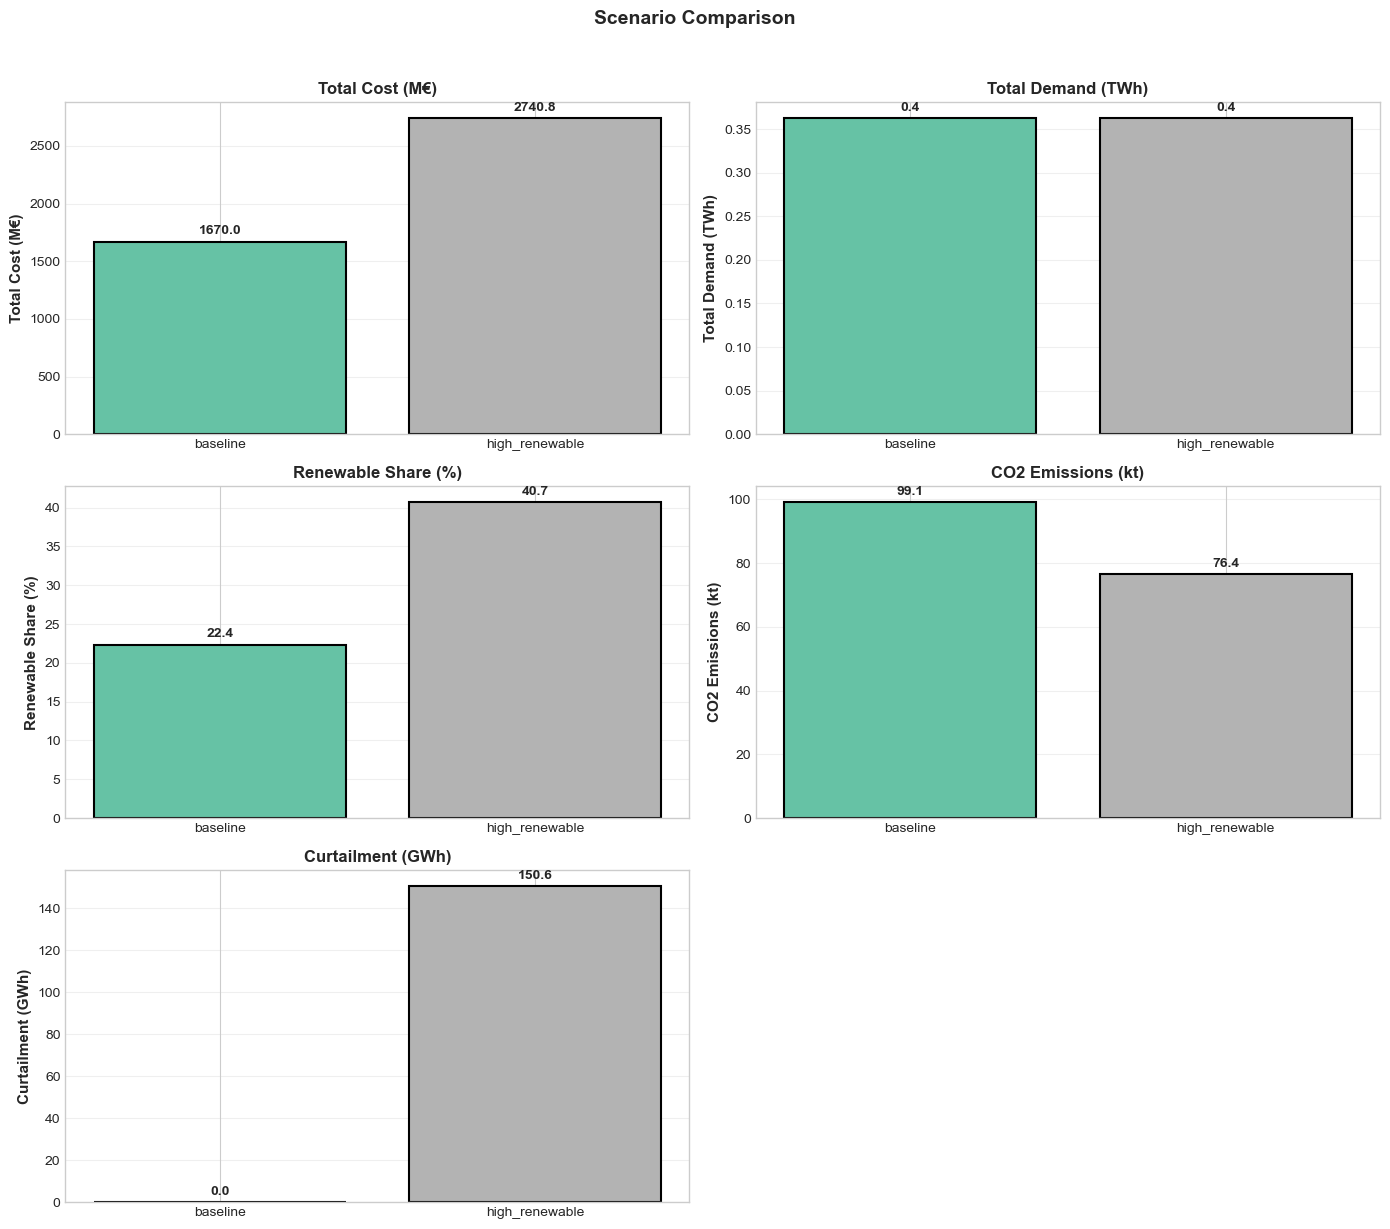

In [15]:
# Create comparison table
if len(all_results) > 1:
    comparison_df = compare_scenarios(all_results)
    display(comparison_df)
    
    # Visual comparison
    fig = plot_scenario_comparison(comparison_df, figsize=(14, 12),
                                 title='Scenario Comparison')
    plt.show()

## 7. Interactive Parameter Exploration

Experiment with different parameters.

In [16]:
# Example: Test different storage capacities
storage_multipliers = [0.5, 1.0, 2.0, 4.0]
results_by_storage = {}

base_config = load_scenario_config('high_renewable')
data = get_data_for_scenario(base_config, data_dir='../data').iloc[:168]

for mult in storage_multipliers:
    print(f"Testing storage multiplier: {mult}x...")
    
    # Modify storage capacity
    config = base_config.copy()
    for storage in config.get('storage_units', []):
        storage['p_nom'] *= mult
    
    # Build and solve
    network = build_network(config, data, f'high_renewable_{mult}x_storage')
    success = run_optimization(network, solver_name='cbc', verbose=False)
    
    if success:
        results = analyze_results(network)
        results_by_storage[f'{mult}x'] = results
        print(f"  Cost: {results['objective_value_eur']/1e6:.2f} M€, "
              f"Renewable: {results['renewable_share']*100:.1f}%")

Testing storage multiplier: 0.5x...
Building network for scenario: high_renewable_0.5x_storage
  Added bus: North
  Added bus: South
  Added line: North_South (North <-> South)
  Added load: North_Load (avg: 969.7 MW)
  Added load: South_Load (avg: 1188.4 MW)
  Added generator: North_Wind (wind, 1500 MW) (extendable)
  Added generator: North_Solar (solar, 400 MW) (extendable)
  Added generator: North_Gas (gas, 100 MW) (extendable)
  Added generator: South_Wind (wind, 600 MW) (extendable)
  Added generator: South_Solar (solar, 2000 MW) (extendable)
  Added generator: South_Gas (gas, 200 MW) (extendable)
  Added storage: North_Battery (400.0 MW, 2400.0 MWh (extendable))
  Added storage: South_Battery (600.0 MW, 3600.0 MWh (extendable))

Network summary:
  Buses: 2
  Lines: 1
  Generators: 6
  Storage Units: 2
  Time steps: 168


INFO:linopy.model: Solve problem using Cbc solver
INFO:linopy.model:Solver options:
 - threads: 4
 - time_limit: 3600
 - log_file: results/solver.log
INFO:linopy.io: Writing time: 0.09s
INFO:linopy.solvers:No match for threads - ? for list of commands
No match for 4 - ? for list of commands
No match for time_limit - ? for list of commands
No match for 3600 - ? for list of commands
No match for log_file - ? for list of commands
No match for results/solver.log - ? for list of commands
Total time (CPU seconds):       0.11   (Wallclock seconds):       0.11


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2192 primals, 5056 duals
Objective: 2.74e+09
Solver model: available
Solver message: Optimal - objective value 2740775930.83691216


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_d

  Cost: 2740.78 M€, Renewable: 40.7%
Testing storage multiplier: 1.0x...
Building network for scenario: high_renewable_1.0x_storage
  Added bus: North
  Added bus: South
  Added line: North_South (North <-> South)
  Added load: North_Load (avg: 969.7 MW)
  Added load: South_Load (avg: 1188.4 MW)
  Added generator: North_Wind (wind, 1500 MW) (extendable)
  Added generator: North_Solar (solar, 400 MW) (extendable)
  Added generator: North_Gas (gas, 100 MW) (extendable)
  Added generator: South_Wind (wind, 600 MW) (extendable)
  Added generator: South_Solar (solar, 2000 MW) (extendable)
  Added generator: South_Gas (gas, 200 MW) (extendable)
  Added storage: North_Battery (400.0 MW, 2400.0 MWh (extendable))
  Added storage: South_Battery (600.0 MW, 3600.0 MWh (extendable))

Network summary:
  Buses: 2
  Lines: 1
  Generators: 6
  Storage Units: 2
  Time steps: 168


INFO:linopy.model: Solve problem using Cbc solver
INFO:linopy.model:Solver options:
 - threads: 4
 - time_limit: 3600
 - log_file: results/solver.log
INFO:linopy.io: Writing time: 0.09s
INFO:linopy.solvers:No match for threads - ? for list of commands
No match for 4 - ? for list of commands
No match for time_limit - ? for list of commands
No match for 3600 - ? for list of commands
No match for log_file - ? for list of commands
No match for results/solver.log - ? for list of commands
Total time (CPU seconds):       0.11   (Wallclock seconds):       0.12


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2192 primals, 5056 duals
Objective: 2.74e+09
Solver model: available
Solver message: Optimal - objective value 2740775930.83691216


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_d

  Cost: 2740.78 M€, Renewable: 40.7%
Testing storage multiplier: 2.0x...
Building network for scenario: high_renewable_2.0x_storage
  Added bus: North
  Added bus: South
  Added line: North_South (North <-> South)
  Added load: North_Load (avg: 969.7 MW)
  Added load: South_Load (avg: 1188.4 MW)
  Added generator: North_Wind (wind, 1500 MW) (extendable)
  Added generator: North_Solar (solar, 400 MW) (extendable)
  Added generator: North_Gas (gas, 100 MW) (extendable)
  Added generator: South_Wind (wind, 600 MW) (extendable)
  Added generator: South_Solar (solar, 2000 MW) (extendable)
  Added generator: South_Gas (gas, 200 MW) (extendable)
  Added storage: North_Battery (800.0 MW, 4800.0 MWh (extendable))
  Added storage: South_Battery (1200.0 MW, 7200.0 MWh (extendable))

Network summary:
  Buses: 2
  Lines: 1
  Generators: 6
  Storage Units: 2
  Time steps: 168


INFO:linopy.model: Solve problem using Cbc solver
INFO:linopy.model:Solver options:
 - threads: 4
 - time_limit: 3600
 - log_file: results/solver.log
INFO:linopy.io: Writing time: 0.1s
INFO:linopy.solvers:No match for threads - ? for list of commands
No match for 4 - ? for list of commands
No match for time_limit - ? for list of commands
No match for 3600 - ? for list of commands
No match for log_file - ? for list of commands
No match for results/solver.log - ? for list of commands
Total time (CPU seconds):       0.13   (Wallclock seconds):       0.13


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2192 primals, 5056 duals
Objective: 2.74e+09
Solver model: available
Solver message: Optimal - objective value 2740775930.83691216


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_di

  Cost: 2740.78 M€, Renewable: 40.7%
Testing storage multiplier: 4.0x...
Building network for scenario: high_renewable_4.0x_storage
  Added bus: North
  Added bus: South
  Added line: North_South (North <-> South)
  Added load: North_Load (avg: 969.7 MW)
  Added load: South_Load (avg: 1188.4 MW)
  Added generator: North_Wind (wind, 1500 MW) (extendable)
  Added generator: North_Solar (solar, 400 MW) (extendable)
  Added generator: North_Gas (gas, 100 MW) (extendable)
  Added generator: South_Wind (wind, 600 MW) (extendable)
  Added generator: South_Solar (solar, 2000 MW) (extendable)
  Added generator: South_Gas (gas, 200 MW) (extendable)
  Added storage: North_Battery (3200.0 MW, 19200.0 MWh (extendable))
  Added storage: South_Battery (4800.0 MW, 28800.0 MWh (extendable))

Network summary:
  Buses: 2
  Lines: 1
  Generators: 6
  Storage Units: 2
  Time steps: 168


INFO:linopy.model: Solve problem using Cbc solver
INFO:linopy.model:Solver options:
 - threads: 4
 - time_limit: 3600
 - log_file: results/solver.log
INFO:linopy.io: Writing time: 0.08s
INFO:linopy.solvers:No match for threads - ? for list of commands
No match for 4 - ? for list of commands
No match for time_limit - ? for list of commands
No match for 3600 - ? for list of commands
No match for log_file - ? for list of commands
No match for results/solver.log - ? for list of commands
Total time (CPU seconds):       0.11   (Wallclock seconds):       0.11


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 2192 primals, 5056 duals
Objective: 2.74e+09
Solver model: available
Solver message: Optimal - objective value 2740775930.83691216


INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Line-fix-s-lower, Line-fix-s-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_d

  Cost: 2740.78 M€, Renewable: 40.7%


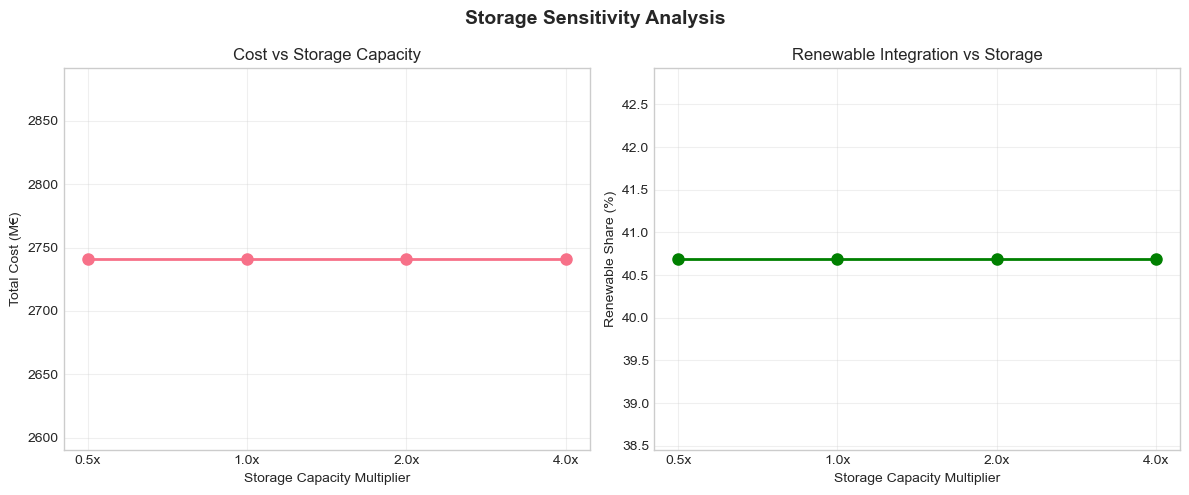

In [17]:
# Plot sensitivity results
if results_by_storage:
    mults = list(results_by_storage.keys())
    costs = [results_by_storage[m]['objective_value_eur']/1e6 for m in mults]
    renewable_shares = [results_by_storage[m]['renewable_share']*100 for m in mults]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].plot(mults, costs, 'o-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Storage Capacity Multiplier')
    axes[0].set_ylabel('Total Cost (M€)')
    axes[0].set_title('Cost vs Storage Capacity')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(mults, renewable_shares, 'o-', linewidth=2, markersize=8, color='green')
    axes[1].set_xlabel('Storage Capacity Multiplier')
    axes[1].set_ylabel('Renewable Share (%)')
    axes[1].set_title('Renewable Integration vs Storage')
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle('Storage Sensitivity Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 8. Export Results

Save results for further analysis.

In [19]:
from datetime import datetime
import os

# Save comparison to CSV
if len(all_results) > 1:
    comparison_df.to_csv('scenario_comparison.csv')
    print("Saved comparison to: scenario_comparison.csv")

# Export network with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

output_dir = r"D:/PypsaExplore/results"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(output_dir, f'optimized_network_{timestamp}.nc')

network.export_to_netcdf(output_file)
print(f"Saved network to: {output_file}")

INFO:pypsa.network.io:Exported network 'Unnamed Network' saved to 'D:/PypsaExplore/results\optimized_network_20260421_135750.nc contains: storage_units, loads, generators, carriers, sub_networks, lines, buses


Saved comparison to: scenario_comparison.csv
Saved network to: D:/PypsaExplore/results\optimized_network_20260421_135750.nc


In [24]:
n = pypsa.Network("D:/PypsaExplore/results\optimized_network_20260421_135750.nc")

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, loads, storage_units, sub_networks
